In [158]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import VisionDataset
import os
from collections import defaultdict
from PIL import Image
from torch.nn.utils.rnn import pad_sequence


In [160]:
class SequenceFolder(VisionDataset):
    """
    Dataset for loading image sequences.

    Expected directory structure

    page_flip_images/
        training/
            page_flip/
                0001_0000.jpg
                0001_0001.jpg
                0001_0002.jpg
                0002_0000.jpg
                0002_0001.jpg
            no_page_flip/
                0003_0000.jpg
                0003_0001.jpg

    Every unique prefix before '_' becomes one training sample.
    """

    IMG_EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp", ".tif")

    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)

        self.samples = []
        self.class_to_idx = {}
        self.classes = []

        self._make_dataset()

    def _make_dataset(self):

        self.classes = sorted(
            d for d in os.listdir(self.root)
            if os.path.isdir(os.path.join(self.root, d))
        )

        self.class_to_idx = {
            cls: i for i, cls in enumerate(self.classes)
        }

        for cls in self.classes:

            class_dir = os.path.join(self.root, cls)

            groups = defaultdict(list)

            for file in sorted(os.listdir(class_dir)):

                if not file.lower().endswith(self.IMG_EXTENSIONS):
                    continue

                sequence_id = file.split("_")[0]

                groups[sequence_id].append(
                    os.path.join(class_dir, file)
                )

            for sequence_id in sorted(groups.keys()):

                image_paths = sorted(groups[sequence_id])

                label = self.class_to_idx[cls]

                self.samples.append((image_paths, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        image_paths, label = self.samples[index]

        images = []

        for path in image_paths:

            image = Image.open(path).convert("RGB")

            if self.transform is not None:
                image = self.transform(image)

            images.append(image)
        
        images = torch.stack(images)
        

        return images, label

In [161]:
def collate_fn(batch):
    videos, labels = zip(*batch)

    
    videos = pad_sequence(videos, batch_first=True)

    labels = torch.tensor(labels)

    return videos, labels

In [162]:
def get_data():

    data_dir = "page_flip_images/"

    transform = transforms.Compose([
        transforms.RandomRotation(20),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224, 224))
    ])

    train_set = SequenceFolder(
        data_dir + "training",
        transform=transform_test,
        
    )

    test_set = SequenceFolder(
        data_dir + "testing",
        transform=transform_test,
        
    )

    train = DataLoader(
        train_set,
        batch_size=16,
        shuffle=True,
        collate_fn=collate_fn
    )

    test = DataLoader(
        test_set,
        batch_size=16,
        shuffle=False,
        collate_fn=collate_fn
    )

    return train, test

In [165]:
get_data()

(<torch.utils.data.dataloader.DataLoader at 0x15136da50>,
 <torch.utils.data.dataloader.DataLoader at 0x15136e650>)

In [164]:
dataset = SequenceFolder("page_flip_images/training")

In [92]:
dataset

Dataset SequenceFolder
    Number of datapoints: 117
    Root location: page_flip_images/training

In [72]:
get_data()

(<torch.utils.data.dataloader.DataLoader at 0x12c687950>,
 <torch.utils.data.dataloader.DataLoader at 0x12d5bb750>)

In [166]:
def train_imshow():
    classes = ('flip', 'notflip') # Defining the classes we have
    dataiter = iter(train)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(figsize=(10, 4), ncols=5)
    for i in range(5):
        ax = axes[i]
        ax.imshow(images[i].permute(1, 2, 0)) 
        ax.title.set_text(' '.join('%5s' % classes[labels[i]]))
    plt.show()

In [168]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv3d(in_channels=3, out_channels=9, kernel_size=3, padding=1),
            nn.MaxPool3d(2, 2, 1),
            nn.Conv3d(in_channels=9, out_channels=27, kernel_size=3, padding=1),
            nn.MaxPool3d(2, 2, 1),
            nn.Conv3d(in_channels=27, out_channels=81, kernel_size=3, padding=1),
            nn.MaxPool3d(2, 2, 1),
         
        )
        self.lstm = nn.LSTM(input_size=68121, hidden_size=128, num_layers=3, batch_first=True)
        self.fc = nn.Linear(128, 2)
      

    def forward(self, x):
        x = x.permute(0, 2, 1, 3, 4)
        out = self.cnn(x)
        out = out.permute(0, 2, 1, 3, 4)
        out = torch.flatten(out, start_dim=2)
        out, _ = self.lstm(out)
        out = self.fc(out[:, -1, :])
        return out
        


In [169]:
net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.01)

In [170]:
if torch.cuda.is_available(): 
    model = net.cuda()
    criterion = criterion.cuda()

def train_net(n_epoch): 
    losses = []
    for epoch in range(n_epoch):  
        running_loss = 0.0
        for i, data in enumerate(train, 0):
            
            inputs, labels = data

            
            optimizer.zero_grad()

            
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            
            losses.append(loss.detach().numpy())
            running_loss += loss.item()
            
            if i % 1 == 0:  
                print('[%d, %5d] loss: %.10f' %
                      (epoch + 1, i + 1, running_loss / 2000))
                running_loss = 0.0
    plt.plot(losses, label='Training loss')
    plt.show()
    print('Finished Training')

[1,     1] loss: 0.0003483386
[1,     2] loss: 0.0004150998
[1,     3] loss: 0.0003443093
[1,     4] loss: 0.0003279080
[1,     5] loss: 0.0003964311
[1,     6] loss: 0.0003181842
[1,     7] loss: 0.0003177896
[1,     8] loss: 0.0003295389
[2,     1] loss: 0.0003845696
[2,     2] loss: 0.0003319391
[2,     3] loss: 0.0003585525
[2,     4] loss: 0.0003236061
[2,     5] loss: 0.0002937278
[2,     6] loss: 0.0003200132
[2,     7] loss: 0.0003086685
[2,     8] loss: 0.0003658949
[3,     1] loss: 0.0002642977
[3,     2] loss: 0.0002331626
[3,     3] loss: 0.0003851226
[3,     4] loss: 0.0002747939
[3,     5] loss: 0.0006038036
[3,     6] loss: 0.0004491137
[3,     7] loss: 0.0002803264
[3,     8] loss: 0.0003066575
[4,     1] loss: 0.0003274692
[4,     2] loss: 0.0002919035
[4,     3] loss: 0.0003024483
[4,     4] loss: 0.0003075079
[4,     5] loss: 0.0002764300
[4,     6] loss: 0.0003085008
[4,     7] loss: 0.0003214043
[4,     8] loss: 0.0003839231
[5,     1] loss: 0.0003624355
[5,     2]

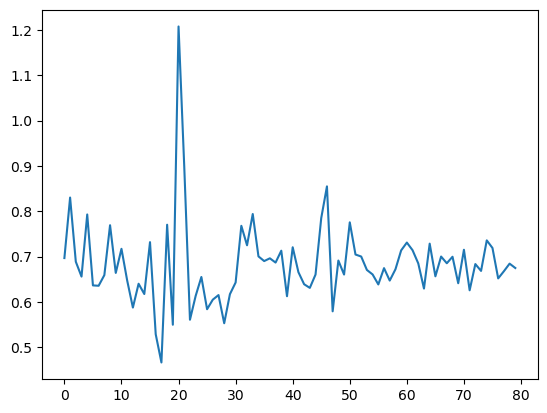

Finished Training


In [171]:
train=get_data()[0]
train_net(10)

In [172]:
PATH5 = './Apziva_Flip_Series5.pth'
torch.save(net.state_dict(), PATH5)


In [173]:
net.load_state_dict(torch.load(PATH5))

<All keys matched successfully>

In [174]:
test = get_data()[1]
correct = 0
total = 0
with torch.no_grad():
    for data in test:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the %d test images: %d %%' % (len(test),
    100 * correct / total))

Accuracy of the network on the 8 test images: 54 %


In [175]:
net.eval()
y_true = []
y_pred = []

for images, labels in test:
    images, labels = data
    outputs = net(images)
    _, predicted = torch.max(outputs, 1)
    y_pred.extend(predicted.cpu().numpy())
    y_true.extend(labels.cpu().numpy())
y_true_tensor = torch.tensor(y_true)
y_pred_tensor = torch.tensor(y_pred)
TP = ((y_pred_tensor == 1) & (y_true_tensor == 1)).sum().item()
FP = ((y_pred_tensor == 1) & (y_true_tensor == 0)).sum().item()
FN = ((y_pred_tensor == 0) & (y_true_tensor == 1)).sum().item()

precision = TP / (TP + FP) if TP + FP > 0 else 0
recall = TP / (TP + FN) if TP + FN > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')

Precision: 0
Recall: 0.0
F1 Score: 0
